In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from autograd import Value
from autograd.draw import Draw

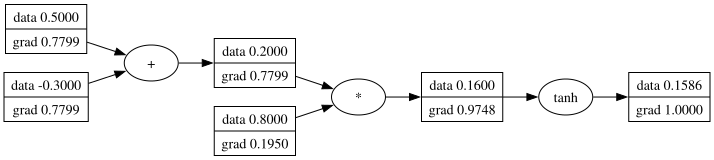

In [3]:
a = Value(0.5)
b = Value(-0.3)
c = a + b
d = Value(0.8)
e = c * d
o = e.tanh()

o.backward()
Draw(o)()

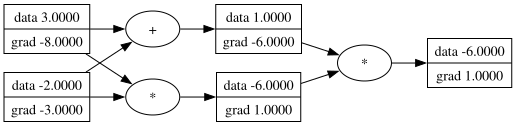

In [4]:
a = Value(-2.0)
b = Value(3.0)
d = a * b
e = a + b
f = d * e

f.backward()
Draw(f)()

In [3]:
from mlp import Neuron, Layer, MLP

In [14]:
model = MLP(2, [4, 4, 1])

In [6]:
x_train = [
    [2.0, 3.0, -1.0],
    [3.0, -1.0, 0.5],
    [0.5, 1.0, 1.0],
    [1.0, 1.0, -1.0]
]
y_train = [1.0, -1.0, -1.0, 1.0]

y_pred = [model(train) for train in x_train]
y_pred

[Value(data=-0.3142, grad=0.0000),
 Value(data=0.1425, grad=0.0000),
 Value(data=-0.3529, grad=0.0000),
 Value(data=-0.3363, grad=0.0000)]

In [20]:
loss = sum((pred - train)**2 for train, pred in zip(y_train, y_pred)) # sum of squared errors (SSE)
loss.data

4.144747174152604

In [17]:
model.zero_grad()
loss.backward()

In [18]:
lr = 0.05

for p in m.parameters():
    p.data += -lr * p.grad

---

In [55]:
from mlp.trainer import Trainer

In [61]:
model = MLP(2, [4, 4, 1])
trainer = Trainer(model, x_train, y_train)

In [62]:
trainer.optimize_with_sse_loss(max_steps=200, target_loss=0.1, start_lr=0.05, end_lr=0.005)

step 0 loss 5.5288
step 1 loss 4.2818
step 2 loss 4.0024
step 3 loss 3.8663
step 4 loss 3.6884
step 5 loss 3.4868
step 6 loss 3.2423
step 7 loss 3.1514
step 8 loss 2.9638
step 9 loss 2.8471
step 10 loss 2.5256
step 11 loss 2.4189
step 12 loss 2.2649
step 13 loss 2.1873
step 14 loss 2.1010
step 15 loss 2.0465
step 16 loss 2.0028
step 17 loss 2.0373
step 18 loss 2.1087
step 19 loss 2.3226
step 20 loss 2.3298
step 21 loss 2.3772
step 22 loss 2.1498
step 23 loss 2.3184
step 24 loss 2.0617
step 25 loss 2.2945
step 26 loss 2.0266
step 27 loss 2.2865
step 28 loss 1.9769
step 29 loss 2.2701
step 30 loss 1.9213
step 31 loss 2.2501
step 32 loss 1.8674
step 33 loss 2.2277
step 34 loss 1.8148
step 35 loss 2.2017
step 36 loss 1.7643
step 37 loss 2.1717
step 38 loss 1.7171
step 39 loss 2.1371
step 40 loss 1.6740
step 41 loss 2.0972
step 42 loss 1.6355
step 43 loss 2.0513
step 44 loss 1.6021
step 45 loss 1.9984
step 46 loss 1.5736
step 47 loss 1.9374
step 48 loss 1.5493
step 49 loss 1.8673
step 50 lo

True